In [1]:
# Relative paths - portable across machines after cloning the repository
from pathlib import Path

DATA_RAW       = Path("../data/raw")
DATA_PROCESSED = Path("../data/processed")


---

## Airport Reviews — ML & Topic Modelling

*Source notebook: `notebook_eda_airports_V1.ipynb`*


Danh sách các cột hiện có: ['review_id', 'airport_id', 'verify', 'date_submitted', 'nationality', 'experience_at_airport', 'type_of_traveller', 'queuing_times', 'terminal_cleanliness', 'terminal_seating', 'terminal_signs', 'food_beverages', 'airport_shopping', 'airport_staff', 'wifi_connectivity', 'recommended', 'data_era', 'sentiment_label', 'sentiment_score', 'data_era_covid']
1. CHẠY MACHINE LEARNING - FEATURE IMPORTANCE
✔️ Số lượng review ĐÃ XÁC THỰC đưa vào mô hình ML: 5,787 dòng


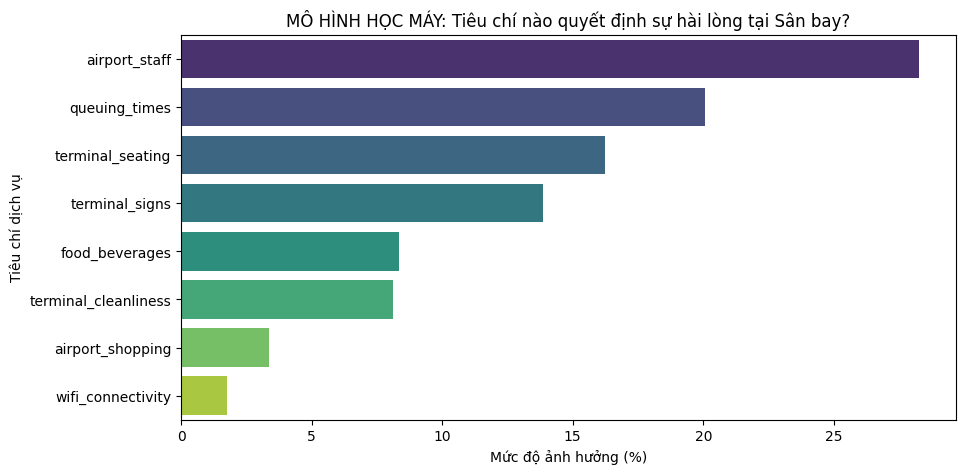

✅ Đã xuất file Trọng số vàng tại: ../data/processed/Feature_Importance_Airports.csv

2. CHẠY TEST TÂM LÝ HỌC - HALO EFFECT
            nhom_xep_hang  terminal_cleanliness  airport_staff
 1. Xếp hàng Tệ (1-2 sao)              2.430735       1.538391
2. Xếp hàng Tốt (4-5 sao)              4.217069       3.736405


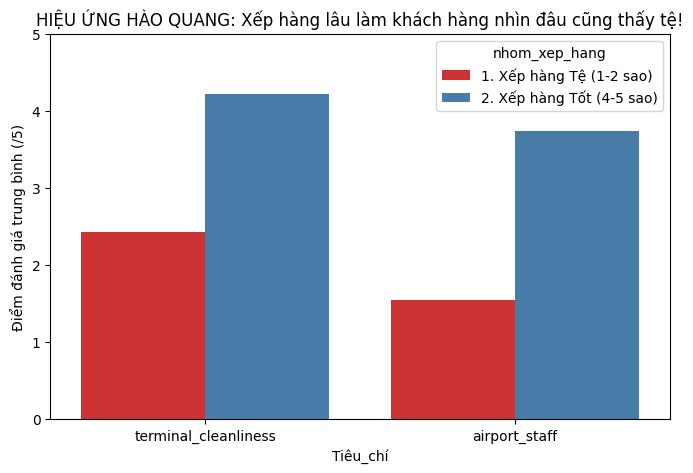


3. PHÂN TÍCH TIẾNG NÓI KHÁCH HÀNG (NLP - LDA)


KeyError: 'clean_keywords'

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from scipy import stats

# ==========================================
# 0. ĐỌC VÀ LỌC SẠCH DỮ LIỆU
# ==========================================
# Lưu ý: Đổi lại tên file gốc của bạn cho chính xác
file_path = DATA_PROCESSED / "airport_reviews_PBI_Master_Optimized.csv"
df_airport = pd.read_csv(file_path)

# THÊM DÒNG NÀY: Xóa toàn bộ khoảng trắng thừa ở đầu/cuối tên tất cả các cột
df_airport.columns = df_airport.columns.str.strip()

# Kiểm tra lại xem danh sách cột đã chuẩn chưa
print("Danh sách các cột hiện có:", df_airport.columns.tolist())

df_airport["date_submitted"] = pd.to_datetime(df_airport["date_submitted"], errors="coerce")

# Lọc năm và tạo tập dữ liệu (chưa lọc verify để lát test ở phần 4)
df_valid = df_airport[df_airport["date_submitted"].dt.year >= 2009].copy()

# ==========================================
# 1. RANDOM FOREST -> TÌM TRỌNG SỐ QUAN TRỌNG NHẤT (XUẤT CSV)
# ==========================================
print("="*60)
print("1. CHẠY MACHINE LEARNING - FEATURE IMPORTANCE")

# ĐÃ CẬP NHẬT HEADER CHÍNH XÁC
features = [
    "queuing_times", "terminal_cleanliness", "terminal_seating", 
    "terminal_signs", "food_beverages", "airport_shopping", "wifi_connectivity", "airport_staff"
]
target = "recommended"

# Chỉ lấy review verified cho mô hình ML
df_ml = df_valid[(df_valid["verify"] == 1) & (df_valid[target].notnull())][features + [target]].dropna()
print(f"✔️ Số lượng review ĐÃ XÁC THỰC đưa vào mô hình ML: {len(df_ml):,} dòng")

X = df_ml[features]
y = df_ml[target]

model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
model.fit(X, y)

importance_scores = pd.DataFrame({
    "criteria_name": features,
    "importance_pct": model.feature_importances_ * 100
}).sort_values(by="importance_pct", ascending=False)

# Trực quan hóa
plt.figure(figsize=(10, 5))
sns.barplot(data=importance_scores, x="importance_pct", y="criteria_name", hue="criteria_name", palette="viridis", legend=False)
plt.title("MÔ HÌNH HỌC MÁY: Tiêu chí nào quyết định sự hài lòng tại Sân bay?")
plt.xlabel("Mức độ ảnh hưởng (%)")
plt.ylabel("Tiêu chí dịch vụ")
plt.show()

# Xuất CSV
path_ml_export = DATA_PROCESSED / "Feature_Importance_Airports.csv"
importance_scores.to_csv(path_ml_export, index=False)
print(f"✅ Đã xuất file Trọng số vàng tại: {path_ml_export}")


# ==========================================
# 2. KIỂM CHỨNG HIỆU ỨNG HÀO QUANG (HALO EFFECT)
# ==========================================
print("\n" + "="*60)
print("2. CHẠY TEST TÂM LÝ HỌC - HALO EFFECT")

# Chia nhóm dựa trên Trải nghiệm Xếp hàng (Queuing)
df_valid["nhom_xep_hang"] = df_valid["queuing_times"].apply(
    lambda x: "1. Xếp hàng Tệ (1-2 sao)" if x <= 2 else ("2. Xếp hàng Tốt (4-5 sao)" if x >= 4 else "Bình thường")
)

df_halo = df_valid[df_valid["nhom_xep_hang"].isin(["1. Xếp hàng Tệ (1-2 sao)", "2. Xếp hàng Tốt (4-5 sao)"])]

# Tính điểm trung bình của Sạch sẽ và Nhân viên
halo_summary = df_halo.groupby("nhom_xep_hang")[["terminal_cleanliness", "airport_staff"]].mean().reset_index()

print(halo_summary.to_string(index=False))

# Trực quan hóa
df_melted = halo_summary.melt(id_vars="nhom_xep_hang", value_vars=["terminal_cleanliness", "airport_staff"], 
                              var_name="Tiêu_chí", value_name="Điểm_trung_bình")
plt.figure(figsize=(8, 5))
sns.barplot(data=df_melted, x="Tiêu_chí", y="Điểm_trung_bình", hue="nhom_xep_hang", palette="Set1")
plt.title("HIỆU ỨNG HÀO QUANG: Xếp hàng lâu làm khách hàng nhìn đâu cũng thấy tệ!")
plt.ylabel("Điểm đánh giá trung bình (/5)")
plt.ylim(0, 5)
plt.show()


# ==========================================
# 3. NLP (LDA) -> 5 CHỦ ĐỀ PHÀN NÀN NHIỀU NHẤT (XUẤT CSV)
# ==========================================
print("\n" + "="*60)
print("3. PHÂN TÍCH TIẾNG NÓI KHÁCH HÀNG (NLP - LDA)")

neg_reviews = df_valid[df_valid["recommended"] == 0]["clean_keywords"].dropna()
print(f"✔️ Đang phân tích chủ đề trên {len(neg_reviews):,} bài review tiêu cực...")

vectorizer = CountVectorizer(max_features=1000, min_df=10)
dtm = vectorizer.fit_transform(neg_reviews)

lda_model = LatentDirichletAllocation(n_components=5, random_state=42, max_iter=10)
lda_model.fit(dtm)

words = vectorizer.get_feature_names_out()
topic_results = lda_model.transform(dtm)
dominant_topics = topic_results.argmax(axis=1)
unique, counts = np.unique(dominant_topics, return_counts=True)
total_neg_reviews = len(neg_reviews)

topic_data = []
for idx, count in zip(unique, counts):
    top_words_idx = lda_model.components_[idx].argsort()[-8:][::-1]
    top_words = ", ".join([words[i] for i in top_words_idx])
    
    topic_data.append({
        "Topic_ID": f"Topic_{idx + 1}",
        "Percentage_%": round((count / total_neg_reviews) * 100, 2),
        "Review_Count": count,
        "Keywords": top_words,
        "Business_Name_EN": "Pending Naming..." # Cập nhật tên sau khi xem Keywords
    })

df_topics = pd.DataFrame(topic_data).sort_values(by="Percentage_%", ascending=False)
print(df_topics[["Topic_ID", "Percentage_%", "Keywords"]].to_string(index=False))

# Xuất CSV
path_nlp_export = DATA_PROCESSED / "NLP_LDA_Topics_Airports.csv"
df_topics.to_csv(path_nlp_export, index=False)
print(f"✅ Đã xuất file Chủ đề NLP tại: {path_nlp_export}")


# ==========================================
# 4. T-TEST: VERIFIED VS UNVERIFIED
# ==========================================
print("\n" + "="*60)
print("4. KIỂM ĐỊNH THỐNG KÊ: BẪY MÀU HỒNG (VERIFIED VS UNVERIFIED)")

# Tách tập dữ liệu dựa trên trạng thái Verify
verified_scores = df_valid[df_valid["verify"] == 1]["recommended"].dropna()
unverified_scores = df_valid[df_valid["verify"] == 0]["recommended"].dropna()

print(f"✈️ Tỷ lệ Hài lòng (Recommended) CÓ XÁC THỰC: {verified_scores.mean()*100:.2f}% (trên {len(verified_scores):,} review)")
print(f"✈️ Tỷ lệ Hài lòng (Recommended) KHÔNG XÁC THỰC: {unverified_scores.mean()*100:.2f}% (trên {len(unverified_scores):,} review)")

# Chạy kiểm định thống kê T-test
t_stat, p_val = stats.ttest_ind(verified_scores, unverified_scores, equal_var=False)

print(f"\n- Chỉ số T-statistic: {t_stat:.4f}")
print(f"- Giá trị P-value: {p_val:.4f} (Quy chuẩn < 0.05 là có ý nghĩa)")

if p_val < 0.05:
    print("🎯 KẾT LUẬN: Sự khác biệt CÓ Ý NGHĨA THỐNG KÊ! Dữ liệu Unverified đang làm 'méo mó' điểm số thật của Sân bay.")
else:
    print("🎯 KẾT LUẬN: Không có sự khác biệt rõ rệt giữa điểm số của tập Verified và Unverified tại Sân bay.")

# Trực quan hóa so sánh
plt.figure(figsize=(6, 5))
sns.barplot(x=["Verified (Xác thực)", "Unverified (Chưa xác thực)"], 
            y=[verified_scores.mean(), unverified_scores.mean()], 
            hue=["Verified (Xác thực)", "Unverified (Chưa xác thực)"],
            palette=["#2ecc71", "#e74c3c"],
            legend=False)
plt.title("SO SÁNH TỶ LỆ HÀI LÒNG: Bẫy màu hồng (Fake vs Real Reviews)")
plt.ylabel("Tỷ lệ Recommended (0 - 1)")
plt.show()